<a href="https://colab.research.google.com/github/MaCuur/AI_EGs/blob/main/lstm_timeseries_multivariado_multistep_mod01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#*FORECASTING* CON REDES LSTM - PARTE 5: MODELO MULTIVARIADO - MULTISTEP

## Contenido

1. [Introducción](#scrollTo=wHQ1yXwrk6CN)
2. [El set de datos](#scrollTo=QDm0J6L-7rGI&line=1&uniqifier=1)
3. [El problema a resolver](#scrollTo=CBJV_YRvj5CZ&line=1&uniqifier=1)
4. [Lectura del set de datos](#scrollTo=Es6L4nEckb3S&line=1&uniqifier=1)
5. [*Feature engineering*](#scrollTo=Ex5fnN-tMD7c&line=25&uniqifier=1)
6. [Pre-procesamiento](#scrollTo=vd5lyqNrlfFg)
7. [Creación y entrenamiento del modelo](#scrollTo=016D9eVw3Beb)
8. [Desempeño del modelo](#scrollTo=ZkI9vr5S69i_)
9. [Predicciones con el modelo entrenado](#scrollTo=fvqk4f8L3aXE&line=1&uniqifier=1)
10. [Conclusiones y sugerencias](#scrollTo=0AFY2trj_KLo&line=1&uniqifier=1)

## 1. Introducción

En el video anterior vimos cómo implementar una Red LSTM donde la entrada es un conjunto de múltiples variables y donde a la salida generamos un sólo instante de predicción a futuro.

En este último video de la serie video veremos un enfoque similar pero con la diferencia de que crearemos un modelo para predecir múltiples instantes de tiempo a futuro sobre una sola variable. Así que hablaremos del modelo multivariado + multistep.

Al igual que en los modelos anteriores, re-utilizaremos buena parte del código desarrollado hasta el momento y  haremos tan sólo algunas modificaciones para implementar este modelo de predicción.

##2. El set de datos

Recordemos que estamos usando el  [weather dataset](https://www.bgc-jena.mpg.de/wetter/weather_data.html), un set de datos que contiene el registro histórico de 14 diferentes variables climáticas en el período entre 2009 y 2015.

En el segundo video de la serie realizamos el análisis exploratorio del dataset y realizamos este pre-procesamiento:

1. Hicimos el manejo de datos faltantes
2. Verificamos que el dataset no tuviese valores extremos
3. Re-interpolamos el dataset para garantizar una periodicidad de 1 hora

Este será el set de datos que usaremos en este tutorial.

##3. El problema a resolver

Crear y entrenar una Red LSTM usando el enfoque multivariado + uni-step:

![](https://drive.google.com/uc?export=view&id=1SeTLqMdmCDh9wXinTXxPij-jkqhOxXOx)

En este caso tomaremos como entrada al modelo 13 covariables (las mismas usadas en el video anterior) y a la salida intentaremos predecir 4 horas de temperatura a futuro (de ahí el término multi-step).

Específicamente, con respecto al video anterior (multivariado-unistep) tendremos que modificar en nuestro código:

1. **El pre-procesamiento** para crear el dataset supervisado con el número instantes de tiempo a predecir (4 horas)
2. **La Red LSTM**, que en lugar de un sólo instante de tiempo ahora debe generar 4 horas consecutivas de predicciones sobre la variable temperatura.

##4. Lectura del set de datos

Recordemos que usaremos el dataset implementado en el [segundo video de la serie](https://youtu.be/R8MEPGn9sFI), sobre el cual ya hemos hecho un pre-procesamiento previo:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Montar Google Drive
# drive.mount('/gdrive')

# Leer set de datos
ruta = '/content/drive/MyDrive/Colab_Notebooks/codificando_bits_egs/multivariado+multistep/'
df = pd.read_csv(ruta+'CEADF_edit.csv', index_col='Fecha')
print(f'DataFrame initial shape: {df.shape}')
df

DataFrame initial shape: (18816, 7)


,Precipitacion(mm),TempMax(°C),TempMin(°C),Evaporacion(mm),TempAmb(°C),Pres Barometric(g/cm²),Hum Relativa(%)
Fecha,,,,,,,
1961-01-01,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-02,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-03,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-04,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-05,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-02-20,0.0,30.0,10.0,5.65,11.0,NaN,NaN
2026-02-21,0.0,31.0,11.0,6.60,11.0,NaN,NaN
2026-02-22,0.0,30.0,10.0,7.65,13.0,NaN,NaN


En este caso **NO** incluiremos la variable tiempo como una covariable, así que podremos eliminarla:

In [ ]:
df = df.iloc[11000:]
display(df.head())
df.info()

,Precipitacion(mm),TempMax(°C),TempMin(°C),Evaporacion(mm),TempAmb(°C),Pres Barometric(g/cm²),Hum Relativa(%)
Fecha,,,,,,,
2003-12-03,0.0,23.0,NaN,NaN,NaN,NaN,NaN
2003-12-04,0.0,24.0,NaN,NaN,NaN,NaN,NaN
2003-12-05,0.0,24.0,NaN,NaN,NaN,NaN,NaN
2003-12-06,0.0,24.5,NaN,NaN,NaN,NaN,NaN
2003-12-07,0.0,24.0,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 7816 entries, 2003-12-03 to 2026-02-24
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Precipitacion(mm)       7816 non-null   float64
 1   TempMax(°C)             7777 non-null   float64
 2   TempMin(°C)             7685 non-null   float64
 3   Evaporacion(mm)         2412 non-null   float64
 4   TempAmb(°C)             895 non-null    float64
 5   Pres Barometric(g/cm²)  0 non-null      float64
 6   Hum Relativa(%)         0 non-null      float64
dtypes: float64(7)
memory usage: 488.5+ KB


In [ ]:
df = df.reset_index()
columns_to_drop_candidates = [
    'Fecha',
    'Pres Barometric(g/cm²)',
    'Evaporacion(mm)',
    'Hum Relativa(%)',
    'TempAmb(°C)',
    'TempMax(°C)',
    'index', # In case 'reset_index' created an 'index' column previously
    'level_0' # In case 'reset_index' created a 'level_0' column previously
]

# Filter out columns that don't exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop_candidates if col in df.columns]

# Only drop if there are existing columns to drop
if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7816 entries, 0 to 7815
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Precipitacion(mm)  7816 non-null   float64
 1   TempMin(°C)        7685 non-null   float64
dtypes: float64(2)
memory usage: 122.3 KB


### Manejo de Valores Faltantes

Identificamos que la columna `TempMax(°C)` contiene valores faltantes. Es crucial manejarlos antes de proceder con la creación del dataset supervisado y el escalamiento para evitar que la pérdida del modelo se convierta en `NaN`.

In [ ]:
# Antes de la partición en train/val/test, se manejan los valores faltantes.
# Se utiliza ffill para rellenar NaNs con el último valor válido conocido,
# lo cual es común en series de tiempo.
# Luego, se usa fillna con la media de la columna para cualquier NaN remanente (ej. al inicio de la serie).

print(f"NaNs en el DataFrame antes de la imputación:\n{df.isnull().sum()}")

for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].ffill() # Forward fill
        df[col] = df[col].fillna(df[col].mean()) # Fill any remaining NaNs (e.g., at the very beginning)

print(f"NaNs en el DataFrame después de la imputación:\n{df.isnull().sum()}")


NaNs en el DataFrame antes de la imputación:
Precipitacion(mm)      0
TempMin(°C)          131
dtype: int64
NaNs en el DataFrame después de la imputación:
Precipitacion(mm)    0
TempMin(°C)          0
dtype: int64


### Visualización de la correlación entre las variables

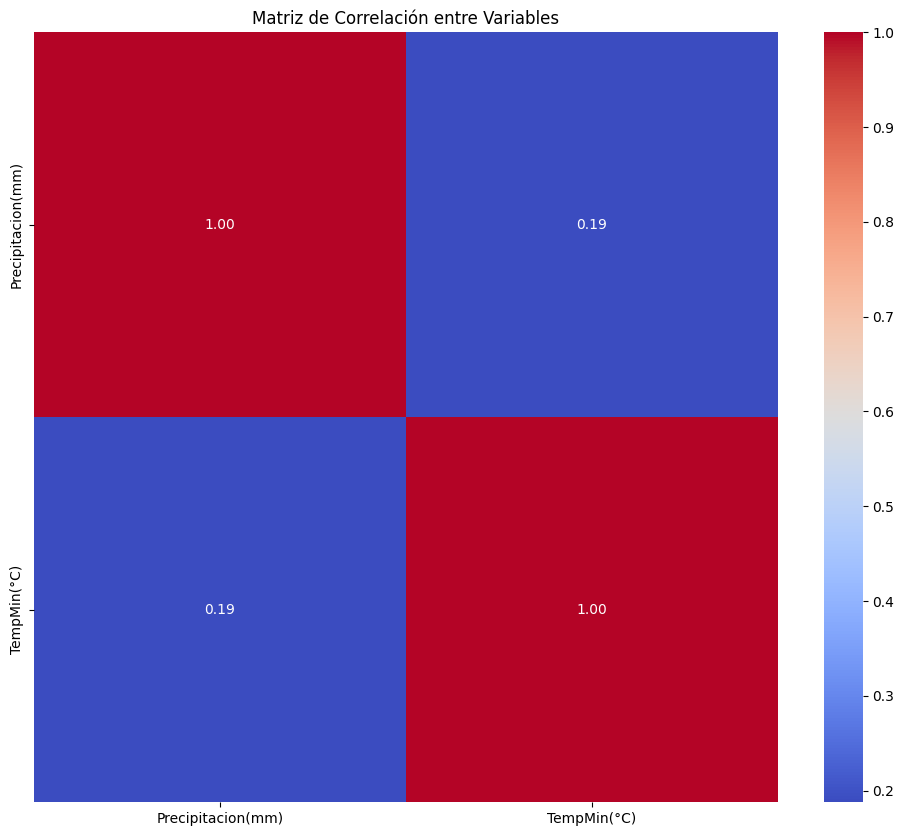

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
correlation_matrix = df.corr()

# Crear un mapa de calor (heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación entre Variables')
plt.show()

##6. Pre-procesamiento

Implica:

1. Partición en train/val/test (80%, 10%, 10%).
2. Generación del dataset supervisado: entrada y salida del modelo
3. Escalamiento

En cada una de estas fases usaremos prácticamente el mismo código usado en los modelos univariados pero con algunas ligeras modificaciones.

### 6.1. Partición del set en entrenamiento, validación y prueba

Esta fase es idéntica a la implementada en el modelo anterior (multivariado - unistep).

A diferencia de otros modelos de Machine Learning, en el caso de series de tiempo **se debe garantizar que se generan las particiones sin mezclar aleatoriamente los datos**.

Recordemos además que:
- El set de entrenamiento (*train*) se usará para encontrar los parámetros del modelo
- El set de validación (*val*) para verificar que no haya *under/over-fitting* del modelo y para ajustar sus hiperparámetros
- El set de prueba (*test*) para poner a prueba el mejor modelo encontrado durante el entrenamiento/validación

En este caso usaremos la misma función implementada para los modelos univariados con la diferencia de que en lugar de introducir una *serie* de Pandas, introduciremos el *DataFrame* completo.

Por tanto, la función retornará tres *dataframes* (train, val y test):

In [ ]:
# Función para generar las particiones preservando las características
# de la serie de tiempo

def train_val_test_split(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    # Definir número de datos en cada subserie
    N = dataframe.shape[0]
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = N - Ntrain - Nval # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain]
    val = dataframe[Ntrain:Ntrain+Nval]
    test = dataframe[Ntrain+Nval:]

    return train, val, test

# Prueba de la función
tr, vl, ts = train_val_test_split(df)

print(f'Tamaño set de entrenamiento: {tr.shape}')
print(f'Tamaño set de validación: {vl.shape}')
print(f'Tamaño set de prueba: {ts.shape}')

Tamaño set de entrenamiento: (6252, 2)
Tamaño set de validación: (781, 2)
Tamaño set de prueba: (783, 2)


Observemos que en lugar de una columna cada subset tiene ahora 13 (correspondientes a las covariables).

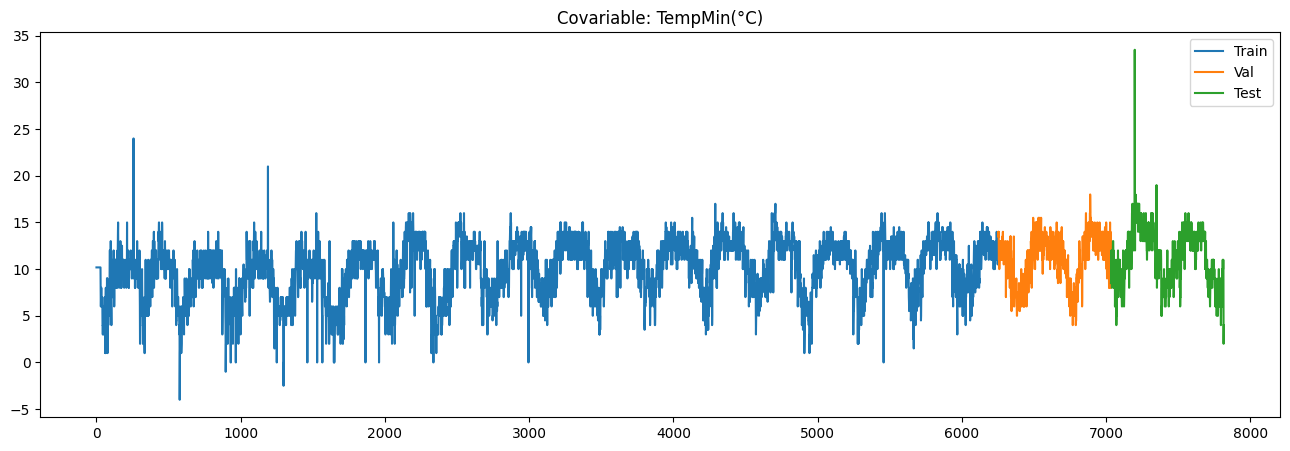

In [ ]:
covar = 1 # Índice de la covariable (columna del dataset) a graficar
col = df.columns[covar]

# Dibujar los sets de entrenamiento/validación/prueba para la covariable
fig, ax = plt.subplots(figsize = (16,5))
ax.plot(tr[col], label='Train')
ax.plot(vl[col], label='Val')
ax.plot(ts[col], label='Test')
ax.set_title(f'Covariable: {col}')
plt.legend();

###6.2 Generación del dataset supervisado (entrada y salida del modelo)

En este caso, con relación al modelo multivariado-multistep, cambiaremos el tamaño del dato de salida pues ahora se generarán 4 horas de predicciones consecutivas.

Debemos ajustar nuestro set de datos de acuerdo a lo especificado en la [documentación de las Redes LSTM en TensorFlow/Keras](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM):

![](https://drive.google.com/uc?export=view&id=1SgWsPot-pAB0upTCSwWoY-KDnJFNMD3A)

Así que en este caso cada dato de entrenamiento será:

- Un arreglo de 24 (horas) x 13 (features) correspondiente a la entrada
- Un arreglo de 4 (horas) x 1 (feature):

![](https://drive.google.com/uc?export=view&id=1ShGZPnrdSkE3HbPgcy26MQcswQlvwc4P)

En este caso, `INPUT_LENGTH` (24 horas) y `OUTPUT_LENGTH`(4 horas) se convertirán en hiperparámetros que más adelante se deberían afinar para mejorar el desempeño del modelo.

Y usaremos la misma función usada en los tutoriales anteriores:

In [ ]:
def crear_dataset_supervisado(array, input_length, output_length, target_col_idx):
    '''Permite crear un dataset con las entradas (X) y salidas (Y)
    requeridas por la Red LSTM.

    Parámetros:
    - array: arreglo numpy de tamaño N x features (N: cantidad de datos,
      f: cantidad de features)
    - input_length: instantes de tiempo consecutivos de la(s) serie(s) de tiempo
      usados para alimentar el modelo
    - output_length: instantes de tiempo a pronosticar (salida del modelo)
    - target_col_idx: índice de la columna que contiene la variable a predecir
    '''

    # Inicialización
    X, Y = [], []    # Listados que contendrán los datos de entrada y salida del modelo
    shape = array.shape
    if len(shape)==3: # Si tenemos sólo una serie (univariado)
        fils, cols = array.shape[0], 2 # 1
        array = array.reshape(fils,cols)
    else: # Multivariado <-- <--- ¡esta parte de la función se ejecuta en este caso!
        fils, cols = array.shape

    # Generar los arreglos
    for i in range(fils-input_length-output_length):
        X.append(array[i:i+INPUT_LENGTH,0:cols])
        # Correctly select the target column using target_col_idx
        Y.append(array[i+input_length:i+input_length+output_length,target_col_idx].reshape(output_length,1))

    # Convertir listas a arreglos de NumPy
    X = np.array(X)
    Y = np.array(Y)

    return X, Y

In [ ]:
# Crear los datasets de entrenamiento, prueba y validación y verificar sus tamaños
INPUT_LENGTH = 15    # Hiperparámetro
OUTPUT_LENGTH = 4    # Modelo multi-step

# Get the index of 'T (degC)' from the dataframe 'df' (after feature engineering)
target_col_idx = df.columns.get_loc('Precipitacion(mm)')

x_tr, y_tr = crear_dataset_supervisado(tr.values, INPUT_LENGTH, OUTPUT_LENGTH, target_col_idx)
x_vl, y_vl = crear_dataset_supervisado(vl.values, INPUT_LENGTH, OUTPUT_LENGTH, target_col_idx)
x_ts, y_ts = crear_dataset_supervisado(ts.values, INPUT_LENGTH, OUTPUT_LENGTH, target_col_idx)

# Imprimir información en pantalla
print('Tamaños entrada (BATCHES x INPUT_LENGTH x FEATURES) y de salida (BATCHES x OUTPUT_LENGTH x FEATURES)')
print(f'Set de entrenamiento - x_tr: {x_tr.shape}, y_tr: {y_tr.shape}')
print(f'Set de validación - x_vl: {x_vl.shape}, y_vl: {y_vl.shape}')
print(f'Set de prueba - x_ts: {x_ts.shape}, y_ts: {y_ts.shape}')

Tamaños entrada (BATCHES x INPUT_LENGTH x FEATURES) y de salida (BATCHES x OUTPUT_LENGTH x FEATURES)
Set de entrenamiento - x_tr: (6233, 15, 2), y_tr: (6233, 4, 1)
Set de validación - x_vl: (762, 15, 2), y_vl: (762, 4, 1)
Set de prueba - x_ts: (764, 15, 2), y_ts: (764, 4, 1)


###6.3 Escalamiento

Esta etapa es idéntica a la implementada en el modelo anterior (multivariado-unistep).

Es requerido para garantizar que todas las características se encuentran en el mismo rango de valores, lo que facilita el entrenamiento del modelo y las predicciones.

En comparación con entradas univariadas, en este caso por tener múltiples variables de entrada se requiere escalar cada una de ellas a la entrada del modelo. Por tanto se creará un total de 13 escaladores (1 por cada covariable).

Sin embargo, a la salida del modelo seguiremos teniendo sólo 1 variable a predecir (la temperatura) y por tanto sólo es necesario escalar dicha variable en el arreglo *Y* de salida:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def escalar_dataset(data_input, col_ref):
    '''Escala el dataset en el rango de -1 a 1.

    Entradas:
    - data_input: diccionario con los dataset de entrada y salida del modelo
    (data_input = {'x_tr':x_tr, 'y_tr':y_tr, 'x_vl':x_vl, 'y_vl':y_vl,
                    'y_ts':y_ts})
    - col_ref: parámetro adicional para especificar la columna que contiene
      la variable a predecir


    Retorna:
    - data_scaled: diccionario con los datasets de entrada y salida escalados
      (tiene la misma estructura del diccionario de entrada)
    - scaler: el escalador usado (requerido para las predicciones)
    '''

    # *** Implementación adicional: determinar el índice de la columna
    # que contiene la variable a predecir
    col_ref = df.columns.get_loc(col_ref)

    # Número de instantes de tiempo de entrada y de covariables
    NSAMPLES = data_input['x_tr'].shape[1]
    NFEATS = data_input['x_tr'].shape[2]

    # Generar listado con "scalers" (1 por cada covariable de entrada)
    scalers = [MinMaxScaler(feature_range=(-1,1)) for i in range(NFEATS)]

    # Arreglos que contendrán los datasets escalados
    x_tr_s = np.zeros(data_input['x_tr'].shape)
    x_vl_s = np.zeros(data_input['x_vl'].shape)
    x_ts_s = np.zeros(data_input['x_ts'].shape)
    y_tr_s = np.zeros(data_input['y_tr'].shape)
    y_vl_s = np.zeros(data_input['y_vl'].shape)
    y_ts_s = np.zeros(data_input['y_ts'].shape)

    # Escalamiento: se usarán los min/max del set de entrenamiento para
    # escalar la totalidad de los datasets

    # Escalamiento Xs
    for i in range(NFEATS):
        x_tr_s[:,:,i] = scalers[i].fit_transform(x_tr[:,:,i])
        x_vl_s[:,:,i] = scalers[i].transform(x_vl[:,:,i])
        x_ts_s[:,:,i] = scalers[i].transform(x_ts[:,:,i])

    # Escalamiento Ys (teniendo en cuenta "col_ind")
    y_tr_s[:,:,0] = scalers[col_ref].fit_transform(y_tr[:,:,0])
    y_vl_s[:,:,0] = scalers[col_ref].transform(y_vl[:,:,0])
    y_ts_s[:,:,0] = scalers[col_ref].transform(y_ts[:,:,0])

    # Conformar diccionario de salida
    data_scaled = {
        'x_tr_s': x_tr_s, 'y_tr_s': y_tr_s,
        'x_vl_s': x_vl_s, 'y_vl_s': y_vl_s,
        'x_ts_s': x_ts_s, 'y_ts_s': y_ts_s,
    }

    return data_scaled, scalers[col_ref]

In [ ]:
# Escalamiento del dataset con la función anterior

# Crear diccionario de entrada
data_in = {
    'x_tr': x_tr, 'y_tr': y_tr,
    'x_vl': x_vl, 'y_vl': y_vl,
    'x_ts': x_ts, 'y_ts': y_ts,
}

# Y escalar (especificando la columna con la variable a predecir)
data_s, scaler = escalar_dataset(data_in, col_ref = 'Precipitacion(mm)' )

# Extraer subsets escalados
x_tr_s, y_tr_s = data_s['x_tr_s'], data_s['y_tr_s']
x_vl_s, y_vl_s = data_s['x_vl_s'], data_s['y_vl_s']
x_ts_s, y_ts_s = data_s['x_ts_s'], data_s['y_ts_s']

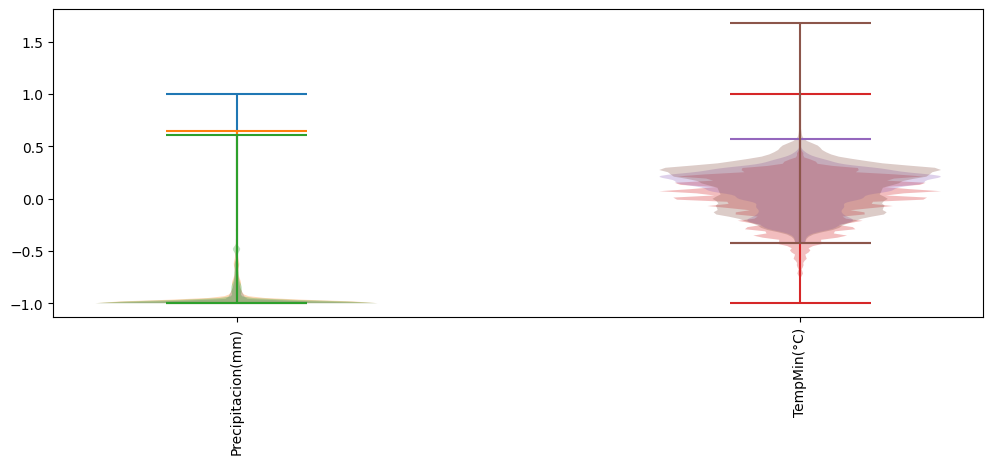

In [ ]:
# Y generemos una gráfica tipo violín para ver la distribución
# de los valores en cada covariable (entrada) y en la variable a
# predecir (salida)

fig, ax = plt.subplots(figsize=(12,4))
for i in range(2):
    ax.violinplot(dataset=x_tr_s[:,:,i].flatten(), positions=[i])
    ax.violinplot(dataset=x_vl_s[:,:,i].flatten(), positions=[i])
    ax.violinplot(dataset=x_ts_s[:,:,i].flatten(), positions=[i])

# Etiquetas eje horizontal
ax.set_xticks(list(range(2)))
ax.set_xticklabels(df.keys(), rotation=90)
ax.autoscale();

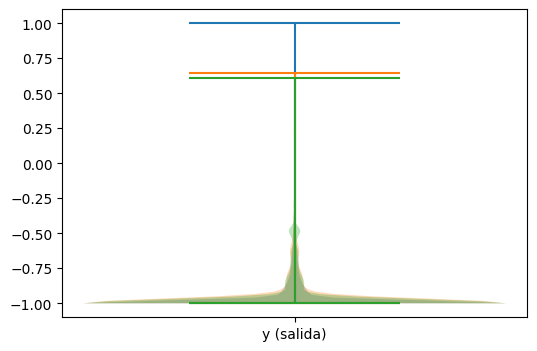

In [ ]:
# Y hagamos lo mismo con la variable de salida:
fig, ax = plt.subplots(figsize=(6,4))
ax.violinplot(dataset=y_tr_s.flatten())
ax.violinplot(dataset=y_vl_s.flatten())
ax.violinplot(dataset=y_ts_s.flatten())
ax.set_xticks([1])
ax.set_xticklabels(['y (salida)']);

##7. Creación y entrenamiento del modelo

- Entradas: arreglos *x* (batches x input-length  x features = batches x 24 x 13)
- Salidas: arreglos *y* (batches x output-length x features = batches x 4 x 1)

Usaremos la raíz cuadrada del error cuadrático medio (o RMSE por sus siglas en Inglés: *root mean square error*) como pérdida para entrenar el modelo:

$RMSE = \sqrt{\frac{\sum_i (y_i-\hat{y_i})^2}{N}}$

donde:
- $y$: temperatura real
- $\hat{y}$: temperatura predicha
- $N$: cantidad de predicciones

In [ ]:
# Creación del modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import RMSprop, Adam
import tensorflow as tf

# Ajustar parámetros para reproducibilidad del entrenamiento
tf.random.set_seed(123)
tf.config.experimental.enable_op_determinism()

# El modelo
N_UNITS = 128 # Tamaño del estado oculto (h) y de la celdad de memoria (c) (128)
INPUT_SHAPE = (x_tr_s.shape[1], x_tr_s.shape[2]) # 24 (horas) x 13 (features)

modelo = Sequential()
modelo.add(LSTM(N_UNITS, input_shape=INPUT_SHAPE))

# Y lo único que cambia con respecto al modelo multivariado + multi-step es
# el tamaño deldato de salida (4 horas)
modelo.add(Dense(OUTPUT_LENGTH, activation='linear')) # activation = 'linear' pues queremos pronosticar (regresión)

# Pérdida: se usará el RMSE (root mean squared error) para el entrenamiento
# pues permite tener errores en las mismas unidades de la temperatura
def root_mean_squared_error(y_true, y_pred):
    rmse = tf.math.sqrt(tf.math.reduce_mean(tf.square(y_pred-y_true)))
    return rmse

# Compilación
optimizador = RMSprop(learning_rate=5e-4) # 5e-5
modelo.compile(
    optimizer = optimizador,
    loss = root_mean_squared_error,
)

# Entrenamiento (aproximadamente 1 min usando GPU)
EPOCHS = 10 # Hiperparámetro
BATCH_SIZE = 64 # Hiperparámetro
historia = modelo.fit(
    x = x_tr_s,
    y = y_tr_s,
    batch_size = BATCH_SIZE,
    epochs = EPOCHS,
    validation_data = (x_vl_s, y_vl_s),
    verbose=2
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


98/98 - 1s - 15ms/step - loss: 0.1927 - val_loss: 0.1552
Epoch 2/10
98/98 - 0s - 5ms/step - loss: 0.1521 - val_loss: 0.1397
Epoch 3/10
98/98 - 1s - 5ms/step - loss: 0.1498 - val_loss: 0.1345
Epoch 4/10
98/98 - 0s - 5ms/step - loss: 0.1486 - val_loss: 0.1345
Epoch 5/10
98/98 - 0s - 5ms/step - loss: 0.1476 - val_loss: 0.1340
Epoch 6/10
98/98 - 1s - 6ms/step - loss: 0.1469 - val_loss: 0.1342
Epoch 7/10
98/98 - 0s - 5ms/step - loss: 0.1464 - val_loss: 0.1345
Epoch 8/10
98/98 - 0s - 5ms/step - loss: 0.1459 - val_loss: 0.1348
Epoch 9/10
98/98 - 1s - 6ms/step - loss: 0.1456 - val_loss: 0.1350
Epoch 10/10
98/98 - 0s - 5ms/step - loss: 0.1453 - val_loss: 0.1352


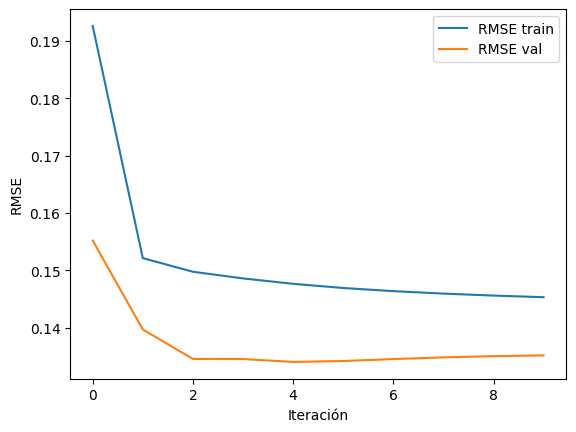

In [ ]:
 # Graficar curvas de entrenamiento y validación
 # para verificar que no existe overfitting
plt.plot(historia.history['loss'],label='RMSE train')
plt.plot(historia.history['val_loss'],label='RMSE val')
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.legend();

**Observaciones y sugerencias:**

- En este caso (modelo multivariado-multistep) el desempeño obtenido (RMSE) es ligeramente inferior al obtenido en el caso del modelo anterior (multivariado-unistep). En este caso el RMSE es del orden de 0.12, mientras que en el modelo del tutorial anterior el desempeño era 0.10.
- En todo caso es importante tener en cuenta que se sugiere afinar los hiperparámetros de cada modelo para poder realizar comparaciones concluyentes.
- Al igual que en el caso del modelo multivariado-unistep en este caso, además de la afinación de hiperparámetros, se sugierer realizar un análisis de *feature importances* para determinar las covariables más relevantes en la predicción.

De nuevo, en la afinación se deberían considerar los siguientes hiperparámetros:
- *INPUT_LENGTH* y *OUTPUT_LENGTH* (esto implica modificar la fase de pre-procesamiento)
- Número de unidades de la Red LSTM
- Pérdida
- Tasa de aprendizaje
- Epochs
- Batch size


## 8. Desempeño del modelo

Suponiendo que el modelo ya ha sido afinado y entrenado, verificaremos su desempeño para el set de prueba y lo compararemos con el desempeño obtenido con los sets de entrenamiento y validación:

In [ ]:
# Cálculo de rmses para train, val y test
rmse_tr = modelo.evaluate(x=x_tr_s, y=y_tr_s, verbose=0)
rmse_vl = modelo.evaluate(x=x_vl_s, y=y_vl_s, verbose=0)
rmse_ts = modelo.evaluate(x=x_ts_s, y=y_ts_s, verbose=0)

# Imprimir resultados en pantalla
print('Comparativo desempeños:')
print(f'  RMSE train:\t {rmse_tr:.3f}')
print(f'  RMSE val:\t {rmse_vl:.3f}')
print(f'  RMSE test:\t {rmse_ts:.3f}')

Comparativo desempeños:
  RMSE train:	 0.116
  RMSE val:	 0.127
  RMSE test:	 0.115


El desempeño para el set de prueba es comparable
(aunque ligeramente inferior) con los sets de entrenamiento y validación y por tanto podemos concluir que el modelo generaliza adecuadamente.

De nuevo, se debería afinar el modelo + realizar análisis de *feature importances* para intentar mejorar el desempeño.

Al igual que hicimos con el modelo univariado-multistep analicemos los errores (RMSEs) individuales para cada una de las horas predichas, para lo cual:

1. Generaremos las predicciones sobre la totalidad del set de prueba con el modelo entrenado.
2. Calcularemos y graficaremos el RMSE para cada instante de tiempo predicho

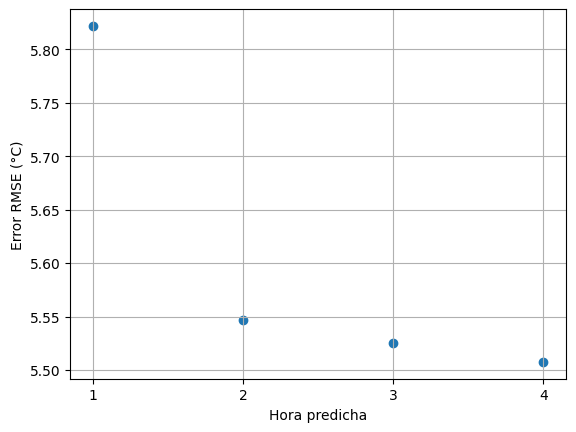

In [ ]:
# 1. Generar las predicciones sobre el set de prueba
y_ts_pred_s = modelo.predict(x_ts_s, verbose=0)

# 2. Realizar la transformación inversa de las predicciones para llevar sus
# valores a la escala original
y_ts_pred = scaler.inverse_transform(y_ts_pred_s)

# 3. Calcular RMSE para cada instante de tiempo predicho
diff_cuad = np.square(y_ts.squeeze()-y_ts_pred) # BATCHESxOUTPUT_LENGTH
proms = np.mean(diff_cuad, axis=0) # 1xOUTPUT_LENGTH
rmse = np.sqrt(proms) # 1xOUTPUT_LENGTH

# Graficar rmse para cada timestep
# Ajustar 't' para que coincida con el OUTPUT_LENGTH real del modelo
t = np.arange(1, OUTPUT_LENGTH + 1)

fig, ax = plt.subplots()
ax.scatter(t,rmse)
ax.set_xlabel('Hora predicha')
ax.set_ylabel('Error RMSE (°C)')
plt.xticks(ticks=t, labels=t)
plt.grid();

Y al igual que ocurría con el modelo univariado-multistep, vemos que en este caso el RMSE se incrementa a medida que nos movemos más hacia adelante en las predicciones.

De nuevo esto es un resultado preliminar y se sugiere afinar los hiperparámetros y realizar un análisis de *feature importances* para intentar mejorar este desempeño.

##9. Predicciones con el modelo entrenado

Suponiendo que el modelo ya ha sido afinado, podemos ponerlo a prueba con el set *test*.

Usaremos la misma función `predecir` usada en los videos anteriores:

In [ ]:
def predecir(x, model, scaler):
    '''Genera la predicción de OUTPUT_LENGTH instantes
    de tiempo a futuro con el modelo entrenado.

    Entrada:
    - x: batch (o batches) de datos para ingresar al modelo
      (tamaño: BATCHES X INPUT_LENGTH X FEATURES)
    - model: Red LSTM entrenada
    - scaler: escalador (requerido para llevar la predicción a la escala original)

    Salida:
    - y_pred: la predicción en la escala original (tamaño: BATCHES X OUTPUT_LENGTH X FEATURES)
    '''

    # Calcular predicción escalada en el rango de -1 a 1
    y_pred_s = model.predict(x,verbose=0)

    # Llevar la predicción a la escala original
    y_pred = scaler.inverse_transform(y_pred_s)

    return y_pred.flatten()

In [ ]:
# Calcular predicciones sobre el set de prueba
y_ts_pred = predecir(x_ts_s, modelo, scaler)

Analicemos este desempeño gráficamente mostrando las temperaturas originales y las predichas por el modelo para cada uno de los datos en el set de prueba:

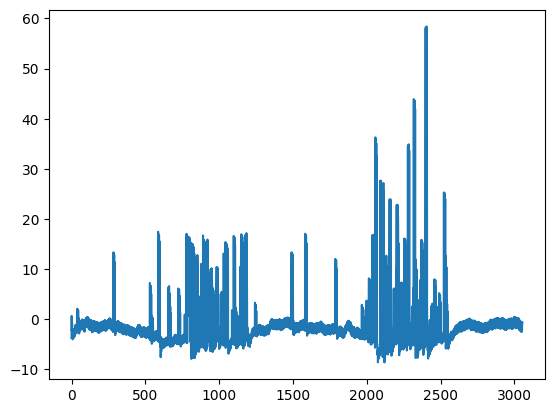

In [ ]:
N = len(y_ts_pred)    # Número de predicciones
ndato = np.linspace(1,N,N)

# Cálculo de errores simples
errores = y_ts.flatten()-y_ts_pred.flatten()
plt.plot(errores);

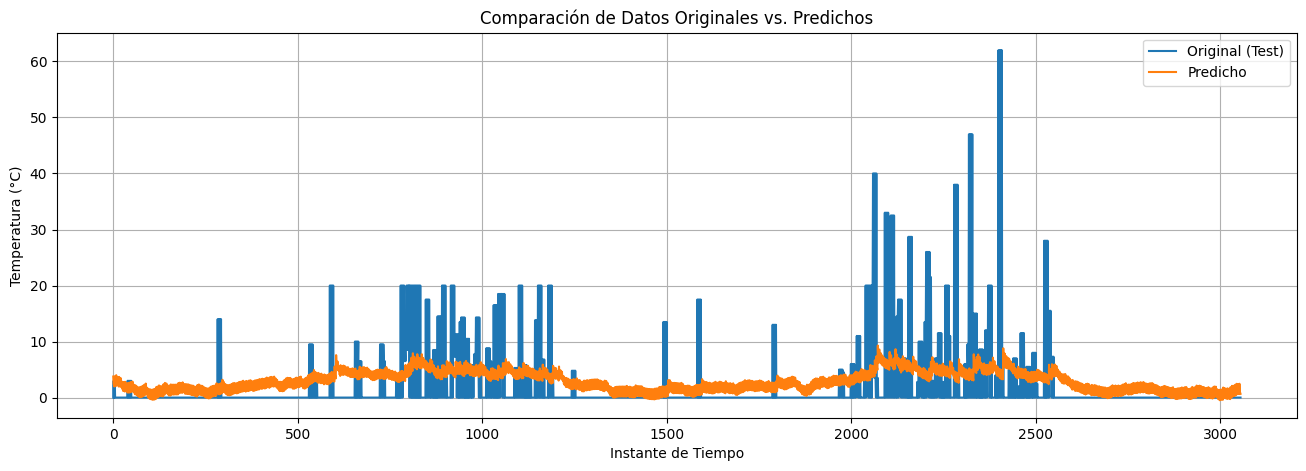

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(y_ts.flatten(), label='Original (Test)')
plt.plot(y_ts_pred, label='Predicho')
plt.title('Comparación de Datos Originales vs. Predichos')
plt.xlabel('Instante de Tiempo')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()

Se observa que:

- El promedio de errores es cercano a cero
- Pero en algunos instantes de tiempo se alcanzan errores extremos de hasta -6 y +5 grados.

Estos errores se podrían reducir al hacer una afinación del modelo o modificando el enfoque de predicción.

In [ ]:
def smape(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator) * 100

smape_value = smape(y_ts.flatten(), y_ts_pred)
print(f'sMAPE para el set de prueba: {smape_value:.2f}%')

sMAPE para el set de prueba: 181.08%


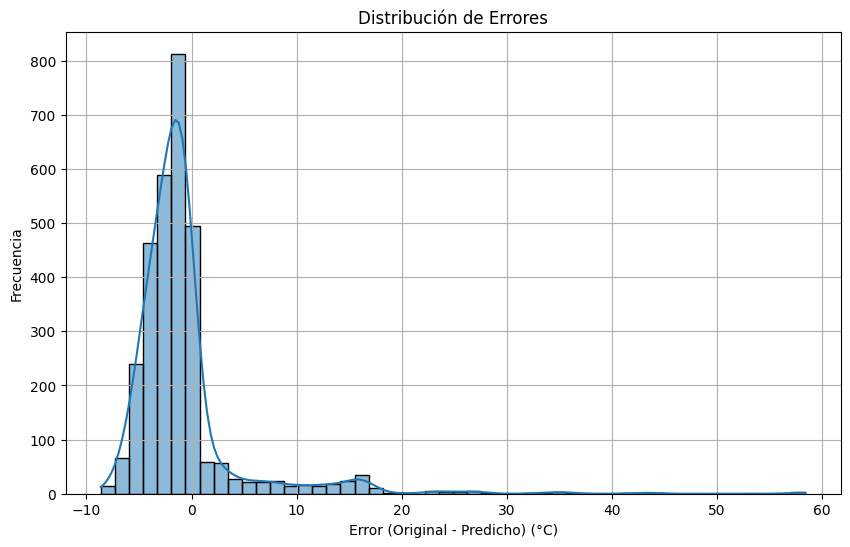

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(errores, bins=50, kde=True)
plt.title('Distribución de Errores')
plt.xlabel('Error (Original - Predicho) (°C)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

## 10. Conclusiones y sugerencias

- Hemos entrenado un cuarto modelo multivariado + multistep
- Al igual que con el modelo multivariado-unistep del video anterior, en este caso hemos incluido una etapa de ingeniería de características antes de crear el dataset supervisado.
- Para intentar mejorar el desempeño del modelo se sugiere afinar sus hiperparámetros y realizar un análisis de *feature importances*.

Y con esto terminamos esta serie de videos en donde hemos visto los principales tipos de enfoques y de Redes LSTM que podemos usar para generar predicciones sobre series de tiempo.

Sin embargo, en estos videos no hemos analizado otros elementos como por ejemplo el uso de la variable tiempo como covariable a la entrada de los modelos, o el análisis de importancia de las características para determinar cuáles covariables son más relevantes durante la predicción. Estos aspectos los podríamos analizar en otros videos más adelante.

## 11. Análisis de Importancia de Características (Feature Importance)

Para entender cuáles características tienen mayor impacto en las predicciones del modelo, realizaremos un análisis de importancia de características usando el método de permutación. Este método consiste en:

1.  Evaluar el desempeño base del modelo (RMSE) en el conjunto de prueba.
2.  Para cada característica:
    a. Mezclar aleatoriamente los valores de esa característica en el conjunto de prueba.
    b. Re-evaluar el modelo con esta característica mezclada.
    c. La degradación en el desempeño (aumento en el RMSE) indica la importancia de la característica. Cuanto mayor sea el aumento, más importante es la característica.



In [ ]:
# 1. Calcular el RMSE base en el set de prueba
baseline_rmse = modelo.evaluate(x_ts_s, y_ts_s, verbose=0)
print(f"RMSE Base en el set de prueba: {baseline_rmse:.4f}")

feature_importances = {}
feature_names = df.columns.tolist()

# 2. Iterar sobre cada característica
for i, feature in enumerate(feature_names):
    # Crear una copia del conjunto de prueba escalado
    x_ts_s_shuffled = x_ts_s.copy()

    # Mezclar la característica actual en todas las muestras y timesteps
    # Asegurarse de que el shuffling se haga de manera consistente para cada característica
    rng = np.random.default_rng(seed=42) # Usar un seed para reproducibilidad
    shuffled_column = rng.permutation(x_ts_s_shuffled[:, :, i].flatten()).reshape(x_ts_s_shuffled[:, :, i].shape)
    x_ts_s_shuffled[:, :, i] = shuffled_column

    # Evaluar el modelo con la característica mezclada
    shuffled_rmse = modelo.evaluate(x_ts_s_shuffled, y_ts_s, verbose=0)

    # Calcular la importancia de la característica
    importance = shuffled_rmse - baseline_rmse
    feature_importances[feature] = importance

# Ordenar las características por importancia
sorted_importances = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)

print("\nImportancia de características (aumento en RMSE):")
for feature, importance in sorted_importances:
    print(f"  {feature}: {importance:.4f}")

RMSE Base en el set de prueba: 0.1147

Importancia de características (aumento en RMSE):
  Precipitacion(mm): 0.0076
  TempMin(°C): 0.0058


/tmp/ipykernel_511/2194399365.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis')


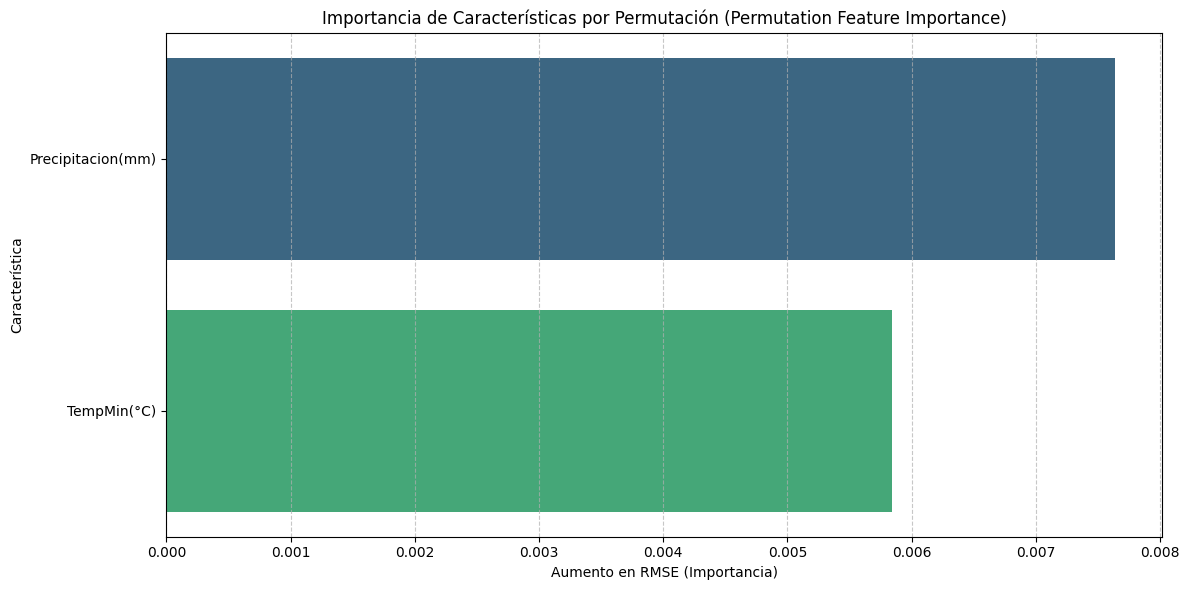

In [ ]:
# 3. Visualizar la importancia de las características

features = [item[0] for item in sorted_importances]
importances = [item[1] for item in sorted_importances]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances, y=features, palette='viridis')
plt.xlabel('Aumento en RMSE (Importancia)')
plt.ylabel('Característica')
plt.title('Importancia de Características por Permutación (Permutation Feature Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 12. Afinación de Hiperparámetros (Hyperparameter Tuning)

La afinación de hiperparámetros es un paso crucial para optimizar el rendimiento de un modelo de Machine Learning. Los hiperparámetros no se aprenden directamente de los datos, sino que son configuraciones que controlan el proceso de entrenamiento. Ajustarlos correctamente puede marcar una gran diferencia en la capacidad del modelo para generalizar y hacer predicciones precisas.

En esta sección, utilizaremos `KerasTuner`, una biblioteca de Google, para automatizar la búsqueda de los mejores hiperparámetros para nuestra Red LSTM. Nos centraremos en optimizar:

*   **`N_UNITS`**: El número de unidades en la capa LSTM.
*   **`learning_rate`**: La tasa de aprendizaje del optimizador.
*   **`BATCH_SIZE`**: El tamaño del lote utilizado durante el entrenamiento.
*   **`EPOCHS`**: El número de épocas de entrenamiento.

*Nota: La afinación de `INPUT_LENGTH` y `OUTPUT_LENGTH` requeriría recrear los datasets supervisados, lo cual es más complejo y generalmente se realiza en una fase de afinación separada.*

In [ ]:
# Instalar KerasTuner
!pip install -q keras-tuner

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import RMSprop, Adam
import tensorflow as tf

# Definir la función de pérdida RMSE
def root_mean_squared_error(y_true, y_pred):
    rmse = tf.math.sqrt(tf.math.reduce_mean(tf.square(y_pred-y_true)))
    return rmse

# Función para construir el modelo con hiperparámetros ajustables
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=256, step=32),
                   input_shape=INPUT_SHAPE))
    model.add(Dense(OUTPUT_LENGTH, activation='linear'))

    # Seleccionar la tasa de aprendizaje
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=RMSprop(learning_rate=hp_learning_rate),
        loss=root_mean_squared_error
    )
    return model

# Inicializar el Tuner (usaremos Hyperband para una búsqueda eficiente)
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,  # Máximo número de epochs para cualquier configuración
    factor=3,       # Factor de reducción para Hyperband
    directory='my_dir',
    project_name='lstm_hyperband_tuning',
    overwrite=True
)

print("Comenzando la búsqueda de hiperparámetros...")

# Ejecutar la búsqueda de hiperparámetros
tuner.search(
    x_tr_s,
    y_tr_s,
    validation_data=(x_vl_s, y_vl_s),
    verbose=1
)

# Obtener los mejores hiperparámetros
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nMejores hiperparámetros encontrados:")
print(f"  Unidades LSTM: {best_hps.get('units')}")
print(f"  Tasa de aprendizaje: {best_hps.get('learning_rate')}")

# Reconstruir y entrenar el modelo con los mejores hiperparámetros
print("\nReentrenando el modelo con los mejores hiperparámetros...")
best_model = tuner.get_best_models(num_models=1)[0]
history_tuned = best_model.fit(
    x_tr_s,
    y_tr_s,
    epochs=EPOCHS, # Usar la constante EPOCHS global
    batch_size=BATCH_SIZE, # Usar la constante BATCH_SIZE global
    validation_data=(x_vl_s, y_vl_s),
    verbose=2
)

# Evaluar el modelo optimizado en el set de prueba
rmse_tuned_ts = best_model.evaluate(x_ts_s, y_ts_s, verbose=0)
print(f"\nRMSE en el set de prueba con hiperparámetros optimizados: {rmse_tuned_ts:.3f}")

Trial 23 Complete [00h 00m 06s]
val_loss: 0.12533552944660187

Best val_loss So Far: 0.12180066853761673
Total elapsed time: 00h 02m 25s

Mejores hiperparámetros encontrados:
  Unidades LSTM: 64
  Tasa de aprendizaje: 0.0001

Reentrenando el modelo con los mejores hiperparámetros...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 7 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


98/98 - 1s - 14ms/step - loss: 0.1443 - val_loss: 0.1315
Epoch 2/10
98/98 - 1s - 11ms/step - loss: 0.1441 - val_loss: 0.1315
Epoch 3/10
98/98 - 0s - 5ms/step - loss: 0.1440 - val_loss: 0.1315
Epoch 4/10
98/98 - 0s - 5ms/step - loss: 0.1438 - val_loss: 0.1315
Epoch 5/10
98/98 - 0s - 5ms/step - loss: 0.1437 - val_loss: 0.1315
Epoch 6/10
98/98 - 1s - 7ms/step - loss: 0.1436 - val_loss: 0.1316
Epoch 7/10
98/98 - 1s - 7ms/step - loss: 0.1436 - val_loss: 0.1316
Epoch 8/10
98/98 - 1s - 13ms/step - loss: 0.1435 - val_loss: 0.1316
Epoch 9/10
98/98 - 1s - 8ms/step - loss: 0.1434 - val_loss: 0.1316
Epoch 10/10
98/98 - 1s - 8ms/step - loss: 0.1434 - val_loss: 0.1317

RMSE en el set de prueba con hiperparámetros optimizados: 0.109


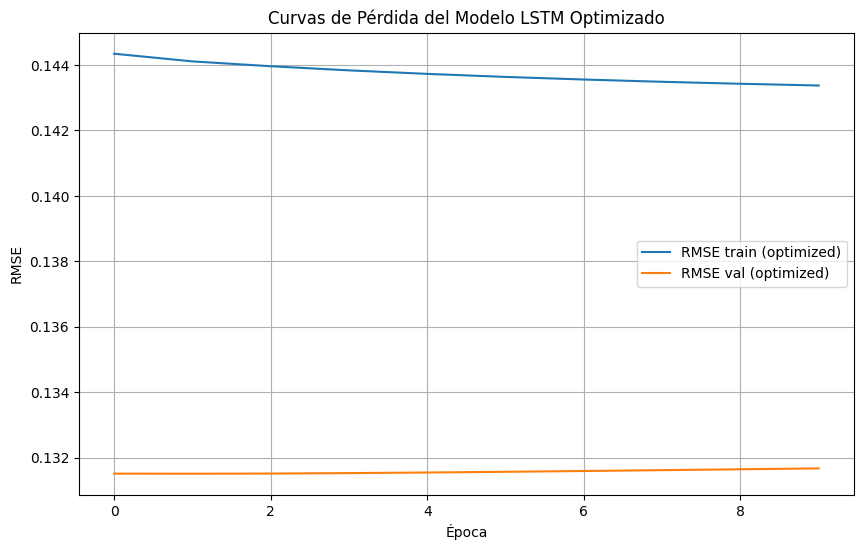

In [ ]:
import matplotlib.pyplot as plt

# Graficar curvas de entrenamiento y validación para el modelo optimizado
plt.figure(figsize=(10, 6))
plt.plot(history_tuned.history['loss'], label='RMSE train (optimized)')
plt.plot(history_tuned.history['val_loss'], label='RMSE val (optimized)')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('Curvas de Pérdida del Modelo LSTM Optimizado')
plt.legend()
plt.grid(True)
plt.show()